# Stage 4 — Link Prediction: ingredient compatibility

**Task:** predict whether two ingredients will appear together in a recipe  
(edge prediction in `ingredient_graph.graphml`)

**Models:**

| Type | Method |
|-----|-------|
| Heuristic | Common Neighbors, Jaccard, Adamic-Adar, Resource Allocation |
| Embeddings | Node2Vec + logistic regression |
| GNN | Graph Autoencoder (GAE with GCN encoder) |

**Metrics:** AUC-ROC, Average Precision  
**Input files:** `output_graphs/ingredient_graph.graphml`, `output_graphs/node_features.npz`

Food-pairing hypothesis (correlation with co-occurrence in recipes): see `06_food_pairing_hypothesis.ipynb`.

In [ ]:
import warnings, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, negative_sampling

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
torch.manual_seed(42)

OUT    = Path('output_graphs')
DEVICE = 'cpu'   # GAE on a sparse graph runs faster and more reliably on CPU
print(f'Device: {DEVICE}')
print('Imports OK')

Device: cpu
Imports OK


## 4.1 Loading the graph and features

In [2]:
print('Loading graph I...')
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')

npz            = np.load(OUT / 'node_features.npz', allow_pickle=True)
feat_nodes     = list(npz['nodes'])
X_full         = npz['X_full'].astype(np.float32)   # (N, 519) struct+chem
X_struct       = npz['X_struct'].astype(np.float32)  # (N, 7) structural only

nodes   = sorted(I.nodes())
node2idx = {n: i for i, n in enumerate(nodes)}
feat_idx = {name: i for i, name in enumerate(feat_nodes)}

N        = len(nodes)
FEAT_DIM = X_full.shape[1]

# Align node ordering: feat_nodes -> nodes
X = np.zeros((N, FEAT_DIM), dtype=np.float32)
for name in nodes:
    if name in feat_idx:
        X[node2idx[name]] = X_full[feat_idx[name]]

print(f'Graph I: {N:,} nodes, {I.number_of_edges():,} edges')
print(f'Feature matrix: {X.shape}')

Loading graph I...
Graph I: 7,199 nodes, 418,645 edges
Feature matrix: (7199, 519)


## 4.2 Edge split: train / val / test

80% of edges for training, 10% for validation, 10% for test.  
For each positive edge we sample one negative (non-existing) edge.

In [3]:
src = [node2idx[u] for u, v in I.edges()]
dst = [node2idx[v] for u, v in I.edges()]
edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)

data = Data(x=torch.tensor(X), edge_index=edge_index, num_nodes=N)

transform = RandomLinkSplit(
    num_val=0.1, num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
)
train_data, val_data, test_data = transform(data)

# Newer PyG versions expose only edge_label_index + edge_label (no pos/neg_edge_label_index)
def get_pos_neg(split):
    pos_mask = split.edge_label.bool()
    neg_mask = ~pos_mask
    return split.edge_label_index[:, pos_mask], split.edge_label_index[:, neg_mask]

train_pos, train_neg = get_pos_neg(train_data)
val_pos,   val_neg   = get_pos_neg(val_data)
test_pos,  test_neg  = get_pos_neg(test_data)

print(f'Train edges (pos): {train_pos.shape[1]:,}')
print(f'Val   edges (pos): {val_pos.shape[1]:,}')
print(f'Test  edges (pos): {test_pos.shape[1]:,}')

Train edges (pos): 334,917
Val   edges (pos): 41,864
Test  edges (pos): 41,864


## 4.3 Heuristic baselines

These require no training — they are computed directly from the graph structure.

In [4]:
def eval_heuristic(G, pos_edges, neg_edges, method):
    edges = list(zip(pos_edges[0].tolist(), pos_edges[1].tolist())) + \
            list(zip(neg_edges[0].tolist(), neg_edges[1].tolist()))
    labels = [1] * pos_edges.shape[1] + [0] * neg_edges.shape[1]

    idx2node = {i: n for n, i in node2idx.items()}
    edge_names = [(idx2node[u], idx2node[v]) for u, v in edges]

    if method == 'cn':
        preds_gen = nx.common_neighbors
        scores = [len(list(preds_gen(G, u, v))) for u, v in edge_names]
    elif method == 'jaccard':
        scores = [p for _, _, p in nx.jaccard_coefficient(G, edge_names)]
    elif method == 'adamic_adar':
        scores = [p for _, _, p in nx.adamic_adar_index(G, edge_names)]
    elif method == 'resource_allocation':
        scores = [p for _, _, p in nx.resource_allocation_index(G, edge_names)]

    auc = roc_auc_score(labels, scores)
    ap  = average_precision_score(labels, scores)
    return auc, ap

idx2node = {i: n for n, i in node2idx.items()}
I_train  = nx.Graph()
I_train.add_nodes_from(nodes)
for i in range(train_pos.shape[1]):
    u, v = idx2node[train_pos[0, i].item()], idx2node[train_pos[1, i].item()]
    I_train.add_edge(u, v)

results = {}
for method in ['cn', 'jaccard', 'adamic_adar', 'resource_allocation']:
    t0 = time.time()
    auc, ap = eval_heuristic(I_train, test_pos, test_neg, method)
    results[method] = {'AUC': auc, 'AP': ap}
    print(f'{method:<25} AUC={auc:.4f}  AP={ap:.4f}  ({time.time()-t0:.1f}s)')

cn                        AUC=0.9465  AP=0.9505  (2.4s)
jaccard                   AUC=0.5268  AP=0.5749  (8.7s)
adamic_adar               AUC=0.9494  AP=0.9543  (4.6s)
resource_allocation       AUC=0.9596  AP=0.9636  (4.8s)


## 4.3.1 Node2Vec + logistic regression

Random-walk baseline on the **train** graph `I_train`.  
Edge features: concatenation of Hadamard product and |L1| difference of node embeddings (`node2vec` → `gensim`).  


> CPU: ~60 minutes

In [7]:
from node2vec import Node2Vec

def n2v_edge_features(zu, zv):
    zu, zv = np.asarray(zu, dtype=np.float64), np.asarray(zv, dtype=np.float64)
    return np.concatenate([zu * zv, np.abs(zu - zv)])


def n2v_rows_for_edges(edge_tensor, idx2node, wv, dim=64):
    rows = []
    for i in range(edge_tensor.shape[1]):
        u, v = edge_tensor[0, i].item(), edge_tensor[1, i].item()
        nu, nv = idx2node[u], idx2node[v]
        zu = np.asarray(wv[nu], dtype=np.float64) if nu in wv else np.zeros(dim)
        zv = np.asarray(wv[nv], dtype=np.float64) if nv in wv else np.zeros(dim)
        rows.append(n2v_edge_features(zu, zv))
    return np.stack(rows, axis=0)


t_n2v = time.time()
# workers=1: avoids joblib pickle errors in Jupyter after numpy version changes (macOS)
node2vec = Node2Vec(
    I_train, dimensions=64, walk_length=30, num_walks=200, workers=1, seed=42,
)
model_n2v = node2vec.fit(window=10, min_count=1, batch_words=4)
idx2node_n2v = {i: n for n, i in node2idx.items()}
wv = model_n2v.wv

rng_lr = np.random.default_rng(42)
max_lr_edges = 50_000
tp, tn = train_pos, train_neg
if tp.shape[1] > max_lr_edges // 2:
    si = rng_lr.choice(tp.shape[1], max_lr_edges // 2, replace=False)
    tp = tp[:, si]
if tn.shape[1] > max_lr_edges // 2:
    si = rng_lr.choice(tn.shape[1], max_lr_edges // 2, replace=False)
    tn = tn[:, si]

X_lr = np.vstack([
    n2v_rows_for_edges(tp, idx2node_n2v, wv),
    n2v_rows_for_edges(tn, idx2node_n2v, wv),
])
y_lr = np.array([1] * tp.shape[1] + [0] * tn.shape[1])
clf_n2v = LogisticRegression(max_iter=500, class_weight='balanced', n_jobs=-1)
clf_n2v.fit(X_lr, y_lr)

X_te = np.vstack([
    n2v_rows_for_edges(test_pos, idx2node_n2v, wv),
    n2v_rows_for_edges(test_neg, idx2node_n2v, wv),
])
y_te = np.array([1] * test_pos.shape[1] + [0] * test_neg.shape[1])
p_te = clf_n2v.predict_proba(X_te)[:, 1]
auc_n2v = roc_auc_score(y_te, p_te)
ap_n2v = average_precision_score(y_te, p_te)
results['Node2Vec+LR'] = {'AUC': float(auc_n2v), 'AP': float(ap_n2v)}
print(f'Node2Vec+LR  AUC={auc_n2v:.4f}  AP={ap_n2v:.4f}  ({time.time() - t_n2v:.1f}s)')

Computing transition probabilities:   0%|          | 0/7199 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [46:52<00:00, 14.06s/it]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.

Node2Vec+LR  AUC=0.9399  AP=0.9331  (5383.4s)


## 4.4 Graph Autoencoder (GAE)

GCN encoder: `519 → 256 → 64`  
Decoder: dot product of embeddings (the standard GAE decoder)

>  ~3–5 minutes (300 epochs on CPU)

In [8]:
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_ch: int, hidden: int, out_ch: int):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden, cached=True)
        self.conv2 = GCNConv(hidden, out_ch, cached=True)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)


model_gae = GAE(GCNEncoder(in_ch=FEAT_DIM, hidden=256, out_ch=64)).to(DEVICE)
opt_gae   = torch.optim.Adam(model_gae.parameters(), lr=1e-2)

train_x       = train_data.x.to(DEVICE)
train_ei      = train_data.edge_index.to(DEVICE)
train_pos_dev = train_pos.to(DEVICE)

losses_gae = []
t0 = time.time()

for epoch in range(1, 301):
    model_gae.train()
    opt_gae.zero_grad()
    z    = model_gae.encode(train_x, train_ei)
    loss = model_gae.recon_loss(z, train_pos_dev)
    loss.backward()
    opt_gae.step()
    losses_gae.append(loss.item())

    if epoch % 50 == 0:
        model_gae.eval()
        with torch.no_grad():
            z_val = model_gae.encode(val_data.x.to(DEVICE), val_data.edge_index.to(DEVICE))
            auc_v, ap_v = model_gae.test(
                z_val,
                val_pos.to(DEVICE),
                val_neg.to(DEVICE)
            )
        print(f'Epoch {epoch:3d}  loss={loss.item():.4f}  '
              f'val AUC={auc_v:.4f}  AP={ap_v:.4f}  {time.time()-t0:.0f}s')

print(f'\nTraining finished in {time.time()-t0:.0f}s')

Epoch  50  loss=0.9264  val AUC=0.9795  AP=0.9813  75s
Epoch 100  loss=0.9041  val AUC=0.9734  AP=0.9785  141s
Epoch 150  loss=0.8952  val AUC=0.9721  AP=0.9781  207s
Epoch 200  loss=0.8898  val AUC=0.9696  AP=0.9765  272s
Epoch 250  loss=0.8909  val AUC=0.9688  AP=0.9762  344s
Epoch 300  loss=0.8859  val AUC=0.9678  AP=0.9758  416s

Training finished in 416s


GAE (test)  AUC=0.9665  AP=0.9745


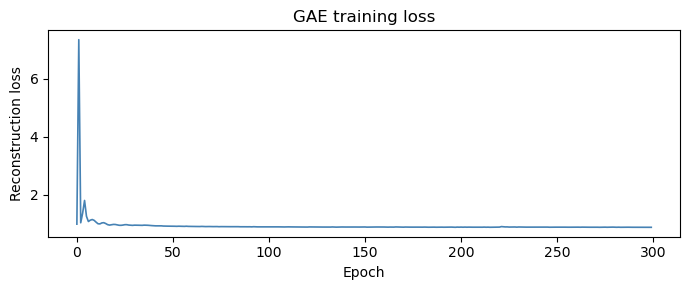

In [9]:
model_gae.eval()
with torch.no_grad():
    z_test = model_gae.encode(
        test_data.x.to(DEVICE),
        test_data.edge_index.to(DEVICE)
    )
    auc_test, ap_test = model_gae.test(
        z_test,
        test_pos.to(DEVICE),
        test_neg.to(DEVICE)
    )

results['GAE'] = {'AUC': auc_test, 'AP': ap_test}
print(f'GAE (test)  AUC={auc_test:.4f}  AP={ap_test:.4f}')

# Loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses_gae, lw=1.2, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Reconstruction loss')
plt.title('GAE training loss')
plt.tight_layout()
plt.savefig(OUT / 'gae_loss_curve.png', dpi=120)
plt.show()

## 4.5 Ablation: GAE without chemical features

Question: do chemical embeddings improve compatibility prediction?

In [10]:
X_s = np.zeros((N, 7), dtype=np.float32)
for name in nodes:
    if name in feat_idx:
        X_s[node2idx[name]] = X_struct[feat_idx[name]]

data_s = Data(x=torch.tensor(X_s), edge_index=edge_index, num_nodes=N)
train_s, val_s, test_s = transform(data_s)
train_s_pos, _         = get_pos_neg(train_s)
test_s_pos,  test_s_neg = get_pos_neg(test_s)

model_struct = GAE(GCNEncoder(in_ch=7, hidden=64, out_ch=32)).to(DEVICE)
opt_s        = torch.optim.Adam(model_struct.parameters(), lr=1e-2)

for epoch in range(1, 301):
    model_struct.train(); opt_s.zero_grad()
    z = model_struct.encode(train_s.x.to(DEVICE), train_s.edge_index.to(DEVICE))
    loss = model_struct.recon_loss(z, train_s_pos.to(DEVICE))
    loss.backward(); opt_s.step()

model_struct.eval()
with torch.no_grad():
    z_s = model_struct.encode(test_s.x.to(DEVICE), test_s.edge_index.to(DEVICE))
    auc_s, ap_s = model_struct.test(
        z_s,
        test_s_pos.to(DEVICE),
        test_s_neg.to(DEVICE)
    )

results['GAE (struct only)'] = {'AUC': auc_s, 'AP': ap_s}
print(f'GAE struct-only  AUC={auc_s:.4f}  AP={ap_s:.4f}')
print(f'GAE full         AUC={auc_test:.4f}  AP={ap_test:.4f}')
delta = auc_test - auc_s
print(f'\nContribution of chemical features: ΔAUC = {delta:+.4f}')

GAE struct-only  AUC=0.9750  AP=0.9808
GAE full         AUC=0.9665  AP=0.9745

Contribution of chemical features: ΔAUC = -0.0085


## 4.6 Results summary

                        AUC      AP
Method                             
GAE (struct only)    0.9750  0.9808
GAE                  0.9665  0.9745
resource_allocation  0.9596  0.9636
adamic_adar          0.9494  0.9543
cn                   0.9465  0.9505
Node2Vec+LR          0.9399  0.9331
jaccard              0.5268  0.5749


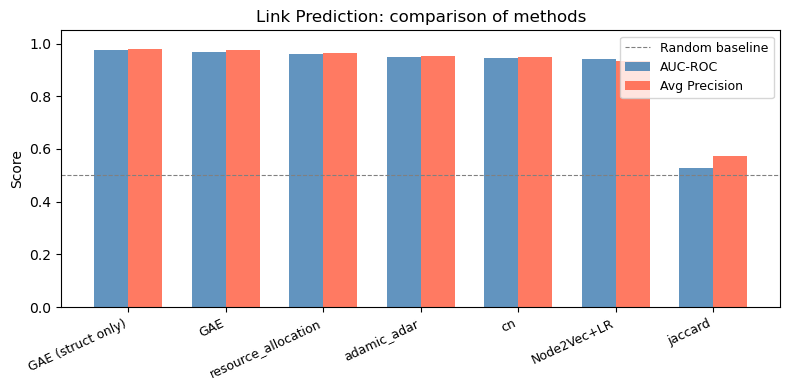

In [11]:
df_res = pd.DataFrame(results).T.round(4)
df_res.index.name = 'Method'
df_res = df_res.sort_values('AUC', ascending=False)
print(df_res.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_res))
w = 0.35
ax.bar(x - w/2, df_res['AUC'], w, label='AUC-ROC', color='steelblue', alpha=0.85)
ax.bar(x + w/2, df_res['AP'],  w, label='Avg Precision', color='tomato', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df_res.index, rotation=25, ha='right', fontsize=9)
ax.axhline(0.5, color='grey', linestyle='--', lw=0.8, label='Random baseline')
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Link Prediction: comparison of methods')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'link_prediction_results.png', dpi=120)
plt.show()

## 4.7 Top predicted pairs (unexpected matches)

In [12]:
model_gae.eval()
with torch.no_grad():
    z_final = model_gae.encode(
        data.x.to(DEVICE), data.edge_index.to(DEVICE)
    ).cpu().numpy()

from sklearn.metrics.pairwise import cosine_similarity

existing_edges = set(map(frozenset, I.edges()))

rng = np.random.default_rng(42)
n_sample = 10_000
candidates = []
while len(candidates) < n_sample:
    u, v = rng.integers(0, N, 2)
    if u != v and frozenset({nodes[u], nodes[v]}) not in existing_edges:
        score = float(np.dot(z_final[u], z_final[v]))
        candidates.append((nodes[u], nodes[v], score))

top_new = sorted(candidates, key=lambda x: -x[2])[:20]
print('Top-20 predicted NEW compatibilities:')
print(f'{"Ingredient A":<25} {"Ingredient B":<25} {"Score":>6}')
print('-' * 60)
for a, b, s in top_new:
    print(f'{a:<25} {b:<25} {s:.4f}')

Top-20 predicted NEW compatibilities:
Ingredient A              Ingredient B               Score
------------------------------------------------------------
onions                    vanilla extract           10.7087
coconut milk              catsup                    5.8474
red                       slivered almonds          4.4928
baking soda               spaghetti                 4.1925
red chili pepper          cranberries               4.1797
butter                    fruit salad               4.1304
warm water                curry                     4.0672
sour sauce                tomatoes                  3.7952
white sugar               low-fat sour cream        3.7124
yellow cake               curry powder              3.7101
lamb                      cocoa                     3.7086
pork sausage              cumin seeds               3.7076
condensed cream           baby spinach              3.6767
tomatoes                  cherry juice              3.5707
light oil      

## 4.8 Saving

In [13]:
np.savez_compressed(
    OUT / 'ingredient_embeddings.npz',
    nodes = np.array(nodes),
    Z     = z_final.astype(np.float32),
)

torch.save(model_gae.state_dict(), OUT / 'gae_model.pt')

df_res.to_csv(OUT / 'link_prediction_scores.csv')

print('Saved:')
for f in ['ingredient_embeddings.npz', 'gae_model.pt',
          'link_prediction_scores.csv', 'link_prediction_results.png']:
    p = OUT / f
    if p.exists():
        print(f'  {f:<40} {p.stat().st_size/1e3:.0f} KB')

print('\n=== Stage 4 summary ===')
print(df_res.to_string())

Saved:
  ingredient_embeddings.npz                1776 KB
  gae_model.pt                             601 KB
  link_prediction_scores.csv               0 KB
  link_prediction_results.png              44 KB

=== Stage 4 summary ===
                        AUC      AP
Method                             
GAE (struct only)    0.9750  0.9808
GAE                  0.9665  0.9745
resource_allocation  0.9596  0.9636
adamic_adar          0.9494  0.9543
cn                   0.9465  0.9505
Node2Vec+LR          0.9399  0.9331
jaccard              0.5268  0.5749
